In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("statistic_store_benchmark.csv")
df['throughput'] = df['num_statistics'] / (df['duration_ms'] / 1000)

# All possible benchmark parameters (excluding benchmark, store_type, repetition, duration_ms)
ALL_PARAMS = ['num_threads', 'num_statistics', 'num_statistic_ids_insert', 'num_statistic_ids_get', 'statistic_size',
              'window_size', 'pct_access_existing', 'pct_insert', 'num_statistics_per_request', 'pct_pre_populate']

df

,benchmark,store_type,num_threads,num_statistics,num_statistic_ids_insert,num_statistic_ids_get,statistic_size,window_size,pct_access_existing,num_statistics_per_request,pct_insert,pct_pre_populate,random_seed,repetition,duration_ms,throughput
0,InsertStatistic,DEFAULT,1,10000000,1,-1,1024,60000,-1,-1,-1,-1,362652400,0,640.07800,1.562310e+07
1,InsertStatistic,DEFAULT,1,10000000,1,-1,1024,60000,-1,-1,-1,-1,362652400,1,631.64100,1.583178e+07
2,InsertStatistic,DEFAULT,1,10000000,1,-1,1024,60000,-1,-1,-1,-1,362652400,2,631.63600,1.583190e+07
3,InsertStatistic,DEFAULT,4,10000000,1,-1,1024,60000,-1,-1,-1,-1,362652400,0,959.81600,1.041866e+07
4,InsertStatistic,DEFAULT,4,10000000,1,-1,1024,60000,-1,-1,-1,-1,362652400,1,870.25200,1.149092e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,GetStatistics,WINDOW,16,100000,100,10,4096,1000,100,100,-1,-1,362652400,1,4.59009,2.178607e+07
752,GetStatistics,WINDOW,16,100000,100,10,4096,1000,100,100,-1,-1,362652400,2,4.55891,2.193507e+07
753,GetStatistics,WINDOW,16,100000,100,10,4096,1000,100,1000,-1,-1,362652400,0,36.38150,2.748650e+06
754,GetStatistics,WINDOW,16,100000,100,10,4096,1000,100,1000,-1,-1,362652400,1,36.40890,2.746581e+06


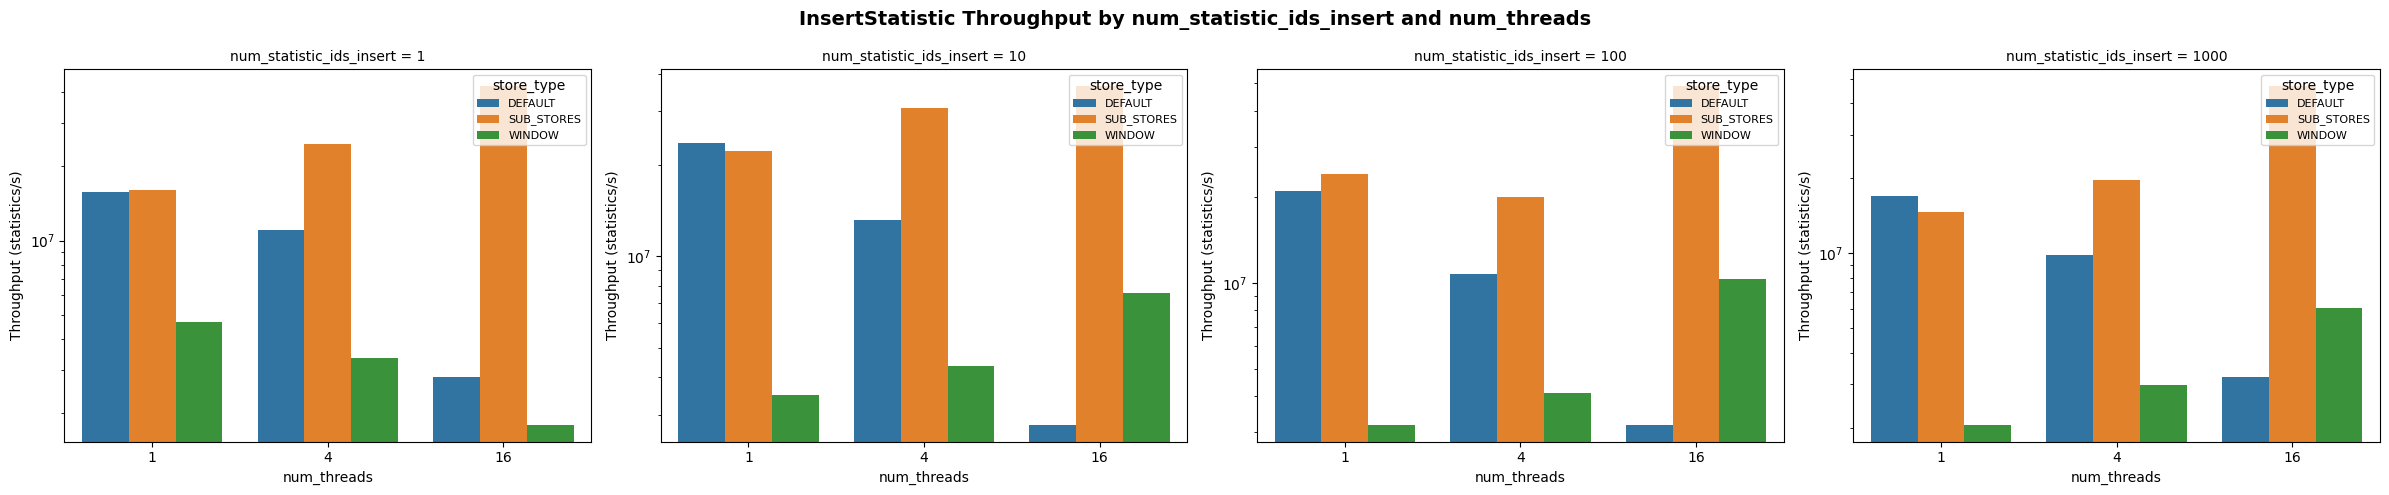

In [2]:
# Insert benchmark: throughput vs num_threads, one subplot per num_statistic_ids_insert
%matplotlib inline

benchmark = 'InsertStatistic'
df_bm = df[df['benchmark'] == benchmark].copy()

if df_bm.empty:
    print(f"No data for {benchmark}")
else:
    relevant = [p for p in ALL_PARAMS if not (df_bm[p] == -1).all()]

    if 'num_statistic_ids_insert' not in relevant or 'num_threads' not in relevant:
        print(f"Skipping {benchmark}: 'num_statistic_ids_insert' or 'num_threads' not found in relevant parameters.")
    else:
        group_cols = ['store_type', 'num_statistic_ids_insert', 'num_threads']
        df_avg = df_bm.groupby(group_cols, as_index=False)[['throughput']].mean()
        df_std = df_bm.groupby(group_cols, as_index=False)[['throughput']].std()
        df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

        num_statistic_ids_values = sorted(df_plot['num_statistic_ids_insert'].unique())
        n = len(num_statistic_ids_values)

        fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)

        for i, num_stat in enumerate(num_statistic_ids_values):
            subset = df_plot[df_plot['num_statistic_ids_insert'] == num_stat]

            ax = axes[0][i]
            sns.barplot(
                data=subset,
                x='num_threads',
                y='throughput_mean',
                hue='store_type',
                ax=ax,
                capsize=0.1,
                err_kws={'linewidth': 1.5},
            )
            ax.set_yscale('log')
            ax.set_xlabel('num_threads')
            ax.set_ylabel('Throughput (statistics/s)')
            ax.set_title(f'num_statistic_ids_insert = {num_stat}', fontsize=10)
            ax.legend(title='store_type', fontsize=8, loc='upper right')

        fig.suptitle(f'{benchmark} Throughput by num_statistic_ids_insert and num_threads', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f"{benchmark}_Throughput_Bars_WithErrorBars.pdf", dpi=300, bbox_inches="tight")
        plt.show()

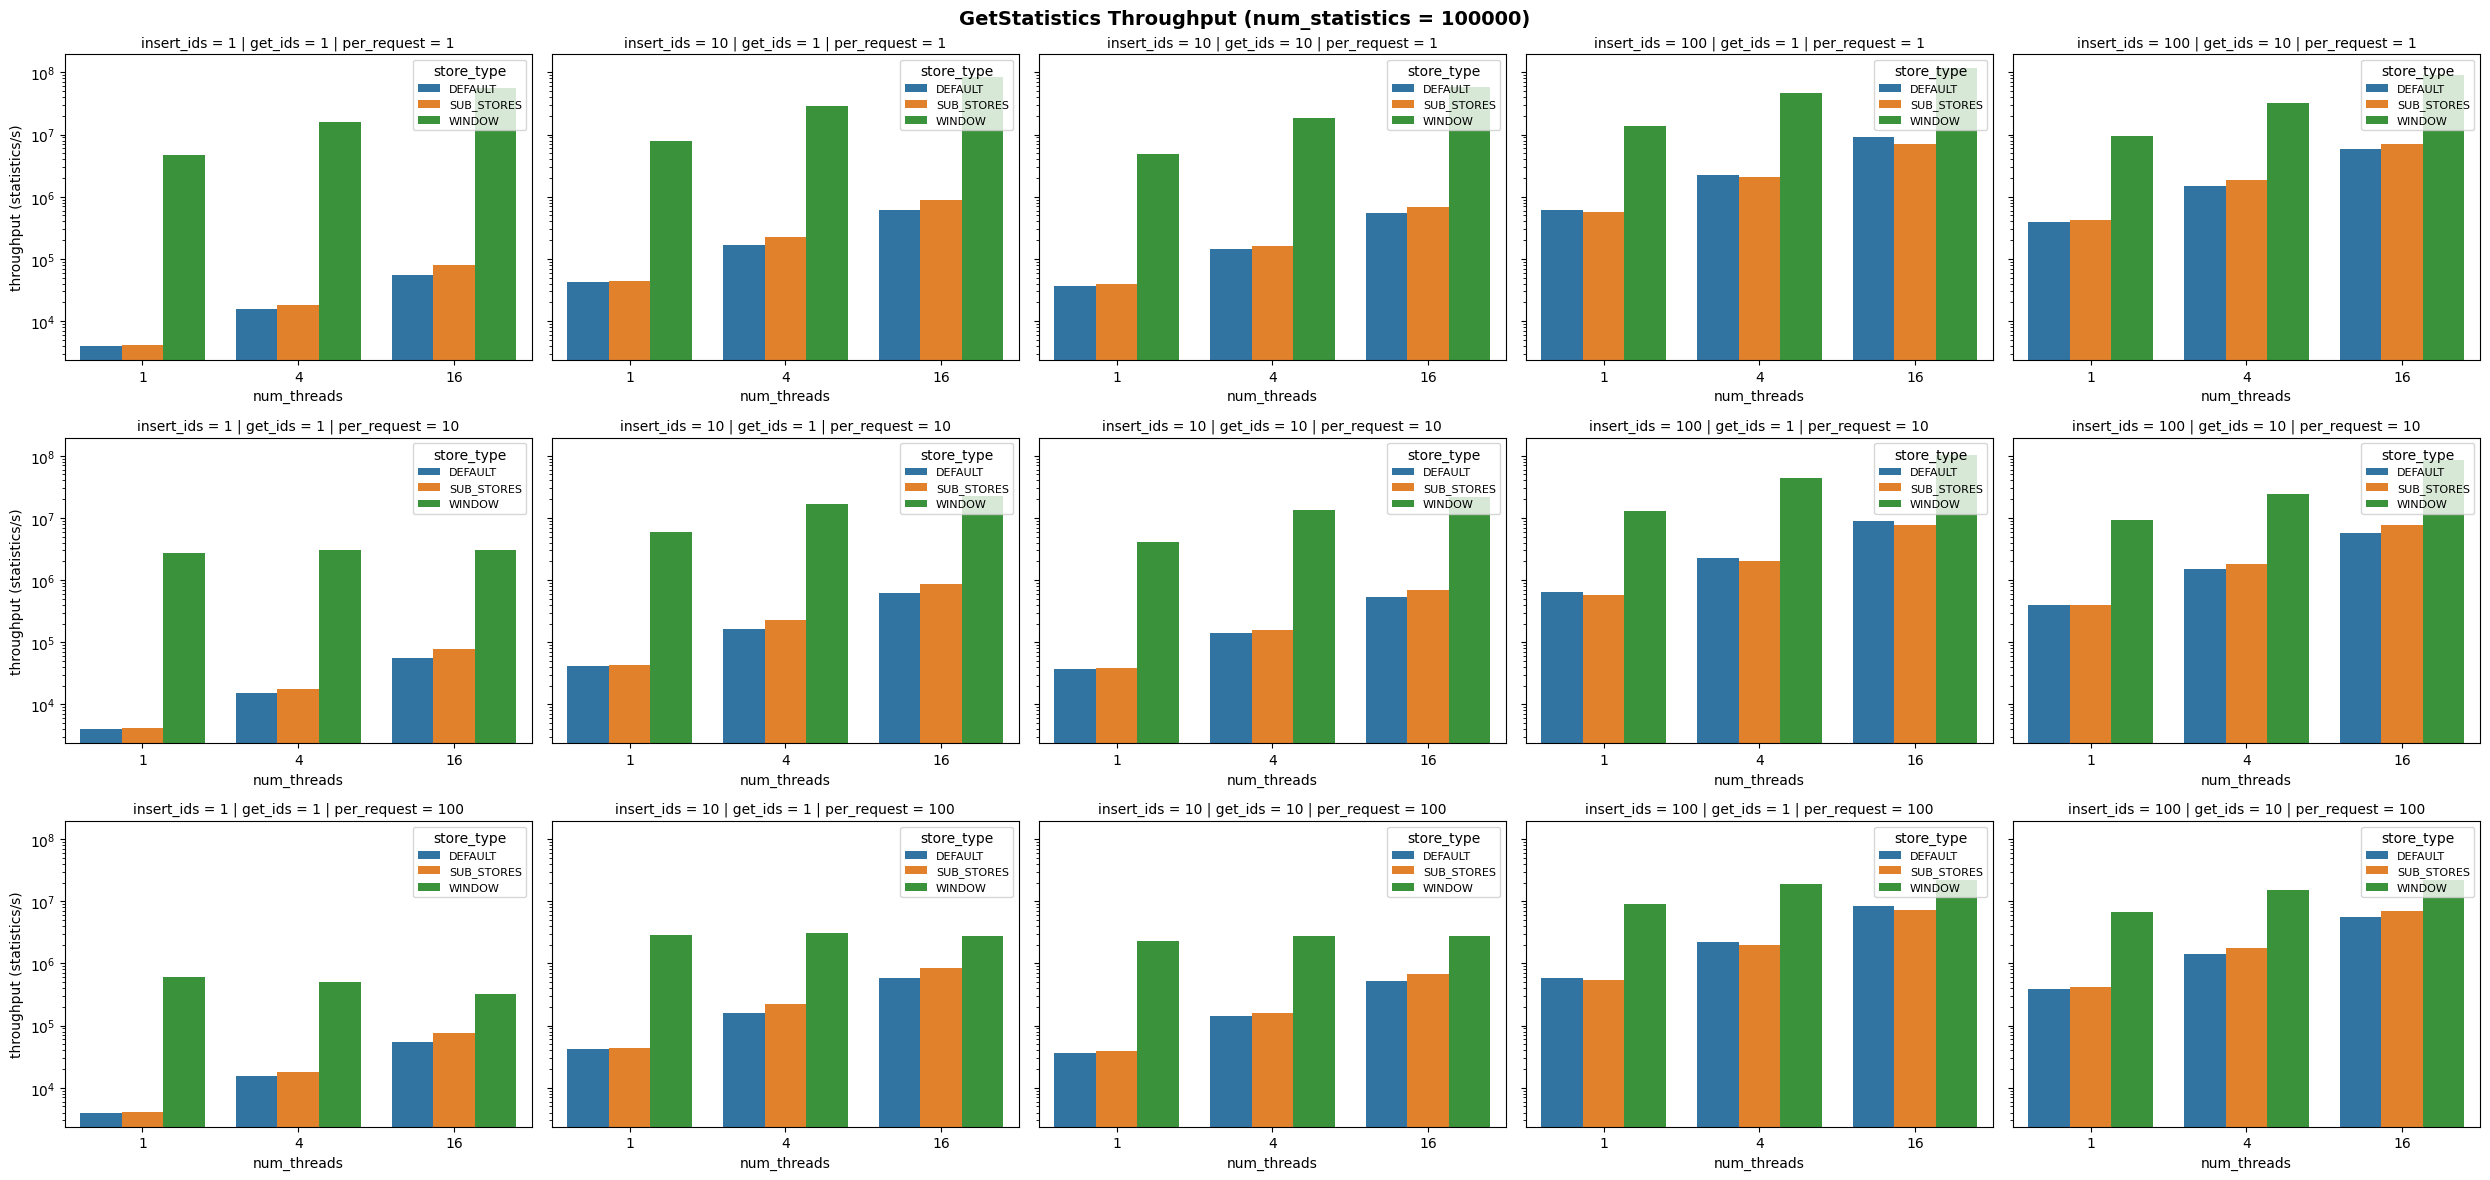

In [3]:
# Get benchmark (num_statistics == 100_000): throughput.
# Grid: cols=(num_statistic_ids_insert, num_statistic_ids_get) pairs, rows=num_statistics_per_request (filtered to 1, 10, 100).
# Within each subplot: throughput (y) vs num_threads (x), grouped by store_type.
%matplotlib inline

benchmark = 'GetStatistics'
target_num_statistics = 100_000
per_request_filter = [1, 10, 100]
excluded_insert_get_pairs = {(1000, 10), (1000, 100)}
df_bm = df[
    (df['benchmark'] == benchmark)
    & (df['num_statistics'] == target_num_statistics)
    & (df['num_statistics_per_request'].isin(per_request_filter))
    & ~df.set_index(['num_statistic_ids_insert', 'num_statistic_ids_get']).index.isin(excluded_insert_get_pairs)
].copy()

if df_bm.empty:
    print(f"No data for {benchmark} with num_statistics == {target_num_statistics}")
else:
    group_cols = ['store_type', 'num_statistic_ids_insert', 'num_statistic_ids_get', 'num_statistics_per_request', 'num_threads']
    df_avg = df_bm.groupby(group_cols, as_index=False)[['throughput']].mean()
    df_std = df_bm.groupby(group_cols, as_index=False)[['throughput']].std()
    df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

    col_values = sorted(
        df_plot[['num_statistic_ids_insert', 'num_statistic_ids_get']].drop_duplicates().itertuples(index=False, name=None)
    )
    row_values = sorted(df_plot['num_statistics_per_request'].unique())
    n_cols = len(col_values)
    n_rows = len(row_values)

    metric_key, y_label, metric_title = 'throughput', 'throughput (statistics/s)', 'Throughput'

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False, sharey=True)

    for r, row_val in enumerate(row_values):
        for c, (insert_val, get_val) in enumerate(col_values):
            ax = axes[r][c]
            subset = df_plot[
                (df_plot['num_statistic_ids_insert'] == insert_val)
                & (df_plot['num_statistic_ids_get'] == get_val)
                & (df_plot['num_statistics_per_request'] == row_val)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.barplot(
                data=subset,
                x='num_threads',
                y=f'{metric_key}_mean',
                hue='store_type',
                ax=ax,
                capsize=0.1,
                err_kws={'linewidth': 1.5},
            )
            ax.set_yscale('log')
            ax.set_xlabel('num_threads')
            ax.set_ylabel(y_label)
            ax.set_title(
                f'insert_ids = {insert_val} | get_ids = {get_val} | per_request = {row_val}',
                fontsize=10,
            )
            ax.legend(title='store_type', fontsize=8, loc='upper right')

    fig.suptitle(
        f'{benchmark} {metric_title} (num_statistics = {target_num_statistics})',
        fontsize=14,
        fontweight='bold',
    )
    plt.tight_layout()
    plt.savefig(
        f"{benchmark}_{metric_title}_numStatistics{target_num_statistics}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

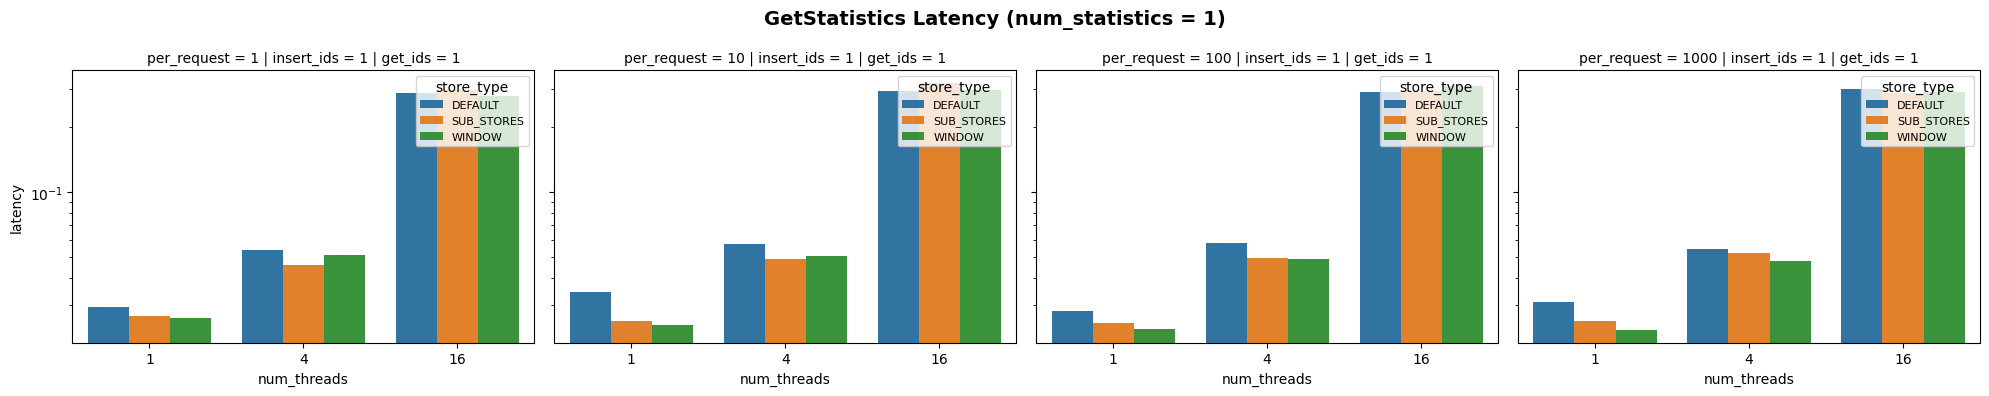

In [4]:
# Get benchmark (num_statistics == 1): latency.
# Grid: cols=num_statistics_per_request, rows=(num_statistic_ids_insert, num_statistic_ids_get) pairs.
# Within each subplot: latency (y) vs num_threads (x), grouped by store_type.
%matplotlib inline

benchmark = 'GetStatistics'
target_num_statistics = 1
df_bm = df[(df['benchmark'] == benchmark) & (df['num_statistics'] == target_num_statistics)].copy()

if df_bm.empty:
    print(f"No data for {benchmark} with num_statistics == {target_num_statistics}")
else:
    # Latency per request in ms; num_statistics is the total number of get requests issued.
    df_bm['latency_ms'] = df_bm['duration_ms'] / df_bm['num_statistics']

    group_cols = ['store_type', 'num_statistic_ids_insert', 'num_statistic_ids_get', 'num_statistics_per_request', 'num_threads']
    df_avg = df_bm.groupby(group_cols, as_index=False)[['latency_ms']].mean()
    df_std = df_bm.groupby(group_cols, as_index=False)[['latency_ms']].std()
    df_plot = pd.merge(df_avg, df_std, on=group_cols, suffixes=('_mean', '_std'))

    col_values = sorted(df_plot['num_statistics_per_request'].unique())
    row_values = sorted(
        df_plot[['num_statistic_ids_insert', 'num_statistic_ids_get']].drop_duplicates().itertuples(index=False, name=None)
    )
    n_cols = len(col_values)
    n_rows = len(row_values)

    metric_key, y_label, metric_title = 'latency_ms', 'latency', 'Latency'

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False, sharey=True)

    for r, (insert_val, get_val) in enumerate(row_values):
        for c, col_val in enumerate(col_values):
            ax = axes[r][c]
            subset = df_plot[
                (df_plot['num_statistic_ids_insert'] == insert_val)
                & (df_plot['num_statistic_ids_get'] == get_val)
                & (df_plot['num_statistics_per_request'] == col_val)
            ]

            if subset.empty:
                ax.set_visible(False)
                continue

            sns.barplot(
                data=subset,
                x='num_threads',
                y=f'{metric_key}_mean',
                hue='store_type',
                ax=ax,
                capsize=0.1,
                err_kws={'linewidth': 1.5},
            )
            ax.set_yscale('log')
            ax.set_xlabel('num_threads')
            ax.set_ylabel(y_label)
            ax.set_title(
                f'per_request = {col_val} | insert_ids = {insert_val} | get_ids = {get_val}',
                fontsize=10,
            )
            ax.legend(title='store_type', fontsize=8, loc='upper right')

    fig.suptitle(
        f'{benchmark} {metric_title} (num_statistics = {target_num_statistics})',
        fontsize=14,
        fontweight='bold',
    )
    plt.tight_layout()
    plt.savefig(
        f"{benchmark}_{metric_title}_numStatistics{target_num_statistics}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()